# Solver wall-time analysis

Timing companion to the optimality-gap analysis. Wall time (`wall_time_ms`) is synthesized across all three solver regimes (**Simulated**, **QPU**, **Hybrid**) and both partition modes (**arbitrary**, **unit**).

For each regime, each partition mode, and each candidate solver, a heatmap shows — in the same (nodes × partitions) format as the optimality-gap heatmaps — the ratio of the solver's **average wall time** to the **ILP solver's average wall time** in that cell. `1×` is parity with the exact ILP solve; `>1×` (red) means slower, `<1×` (blue) means faster.

> Note: for the QPU and Hybrid regimes, `wall_time_ms` is end-to-end wall clock and therefore includes cloud submission, queueing and network round-trips, not just on-device anneal/solve time. Finer fields (`qpu_access_time_us`, `run_time_us`) exist in the data if a device-only comparison is wanted later.

Plots are saved to the `plots/` directory alongside this notebook.

In [1]:
# --- Configuration -----------------------------------------------------------
# This notebook synthesizes WALL TIME across the three solver regimes. Each
# regime has an arbitrary-partition file and a unit-partition file; they share
# the same (nodes x partitions) grid, so they are kept as SEPARATE heatmaps.
from pathlib import Path

# Resolve the repo root robustly: works whether the notebook is opened on the
# original machine or executed elsewhere (e.g. a mounted copy).
CANDIDATE_ROOTS = [
    Path(r"/Users/danielarturi/Desktop/Quantum/QuantumClean"),
    Path(r"/sessions/vibrant-bold-pasteur/mnt/QuantumClean"),
    Path.cwd(),
    Path.cwd().parent,
]
REPO_ROOT = next((p for p in CANDIDATE_ROOTS if (p / "result_bank").exists()), Path.cwd())

OUTPUT_DIR = Path(r"/sessions/vibrant-bold-pasteur/mnt/QuantumClean/result_analysis")
PLOTS_DIR  = Path(r"/sessions/vibrant-bold-pasteur/mnt/QuantumClean/result_analysis/plots")
if not OUTPUT_DIR.exists():            # fall back to repo-relative when the
    OUTPUT_DIR = REPO_ROOT / "result_analysis"   # hard-coded path is absent
    PLOTS_DIR  = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_SOLVER = "ILP"   # baseline whose wall time every candidate is divided by
TIME_FIELD       = "wall_time_ms"  # the wall-clock field recorded for every solver

# regime -> partition mode -> results file (relative to result_bank/)
REGIMES = {
    "Simulated": {
        "arbitrary": "simulated_solver_results_feasible/ArbitraryExperiment_1.json",
        "unit":      "simulated_solver_results_feasible/UnitExperiment_1.json",
    },
    "QPU": {
        "arbitrary": "quantum_hardware_results_feasible/ArbTier1Full_S1_S2_1.json",
        "unit":      "quantum_hardware_results_feasible/Tier1Full_S1_S2_1.json",
    },
    "Hybrid": {
        "arbitrary": "hybrid_results_feasible/ArbTier1Final_S1S2_HYB_1_merged.json",
        "unit":      "hybrid_results_feasible/Tier1Final_S1S2_HYB_merged.json",
    },
}

print("Repo root :", REPO_ROOT)
print("Plots dir :", PLOTS_DIR)

Repo root : /sessions/vibrant-bold-pasteur/mnt/QuantumClean
Plots dir : /sessions/vibrant-bold-pasteur/mnt/QuantumClean/result_analysis/plots


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

## Build the tidy wall-time table

In [3]:
# --- Load + flatten every file into one tidy wall-time table -----------------
# One row per (regime, partition mode, case, candidate solver). We keep a row
# only when BOTH that solver AND the reference ILP recorded a numeric wall time
# for the case, so each ratio is computed on a like-for-like pair. Wall time is
# kept regardless of solution validity: it is the cost of *running* the solver.
def numeric(x):
    return x if isinstance(x, (int, float)) and not isinstance(x, bool) else None

rows = []
for regime, modes in REGIMES.items():
    for mode, rel in modes.items():
        path = REPO_ROOT / "result_bank" / rel
        raw = json.loads(path.read_text())
        results = raw["results"] if isinstance(raw, dict) and "results" in raw else raw
        for case_key, case in results.items():
            solvers = case.get("solvers", {})
            ilp = solvers.get(REFERENCE_SOLVER, {})
            ilp_t = numeric(ilp.get(TIME_FIELD)) if isinstance(ilp, dict) else None
            if ilp_t is None:
                continue  # no baseline wall time -> ratio undefined for this case
            for sname, block in solvers.items():
                if sname == REFERENCE_SOLVER or not isinstance(block, dict):
                    continue
                s_t = numeric(block.get(TIME_FIELD))
                if s_t is None:
                    continue
                rows.append({
                    "regime": regime,
                    "mode": mode,
                    "case": case_key,
                    "solver": sname,
                    "n_nodes": case.get("n_nodes"),
                    "n_partitions": case.get("n_partitions"),
                    "solver_wall_ms": float(s_t),
                    "ilp_wall_ms": float(ilp_t),
                })

df = pd.DataFrame(rows)
print(f"{len(df)} (case x candidate-solver) wall-time pairs loaded")
print(df.groupby(["regime", "mode"])["solver"].agg(["count", "nunique"]))
df.head()

1476 (case x candidate-solver) wall-time pairs loaded
                     count  nunique
regime    mode                     
Hybrid    arbitrary     72        2
          unit          72        2
QPU       arbitrary    306        2
          unit         306        2
Simulated arbitrary    360        2
          unit         360        2


,regime,mode,case,solver,n_nodes,n_partitions,solver_wall_ms,ilp_wall_ms
0,Simulated,arbitrary,n-3_p-12_1__t30,SQA,3,12,3548.8,24.1
1,Simulated,arbitrary,n-3_p-12_1__t30,SQA_SF,3,12,1595.8,24.1
2,Simulated,arbitrary,n-3_p-12_2__t30,SQA,3,12,3730.5,22.3
3,Simulated,arbitrary,n-3_p-12_2__t30,SQA_SF,3,12,1612.4,22.3
4,Simulated,arbitrary,n-3_p-12_3__t30,SQA,3,12,3794.2,23.0


In [4]:
# --- Ratio-heatmap helper ----------------------------------------------------
# Same (rows = n_nodes, cols = n_partitions) grid as the optimality-gap heatmaps.
# Per cell: mean(solver wall) / mean(ILP wall). Colour is log10(ratio) so that a
# wide dynamic range stays readable and the map diverges about parity (1x):
#   red  -> solver slower than ILP   (ratio > 1)
#   blue -> solver faster than ILP   (ratio < 1)
# Cells are annotated with the actual ratio (e.g. "42x").
def fmt_ratio(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return ""
    if v >= 100:   return f"{v:.0f}×"
    if v >= 10:    return f"{v:.1f}×"
    return f"{v:.2f}×"

def ratio_heatmap(pivot, title, fname):
    """pivot: DataFrame of ratios indexed by n_nodes, columns n_partitions."""
    if pivot.empty or pivot.isna().all().all():
        print(f"  (no wall-time data for: {title})")
        return
    logp = np.log10(pivot.astype(float))
    finite = np.abs(logp.values[np.isfinite(logp.values)])
    vmax = float(finite.max()) if finite.size else 1.0
    vmax = max(vmax, 0.3)

    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            annot[i, j] = fmt_ratio(pivot.values[i, j])

    fig, ax = plt.subplots(figsize=(max(5, 0.8 * pivot.shape[1] + 2),
                                    max(4, 0.7 * pivot.shape[0] + 2)))
    sns.heatmap(logp, annot=annot, fmt="", cmap="coolwarm", center=0,
                vmin=-vmax, vmax=vmax, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "log₁₀(solver ÷ ILP wall time)   (0 = parity)"},
                ax=ax)
    ax.set_xlabel("Number of partitions")
    ax.set_ylabel("Number of nodes")
    ax.set_title(title)
    ax.invert_yaxis()  # smaller node counts at the bottom, matching the optgap maps
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

def slug(s):
    return str(s).replace(" ", "").replace("/", "_")

## Wall-time ratio heatmaps

One heatmap per candidate solver, per partition mode, per regime (arbitrary and unit partitions kept separate).


================  Simulated  ================


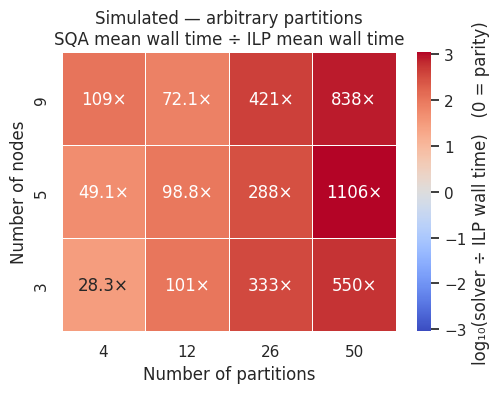

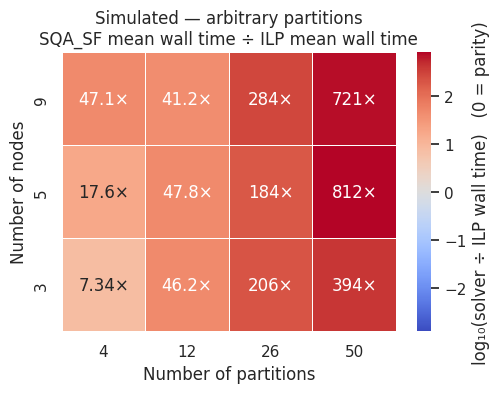

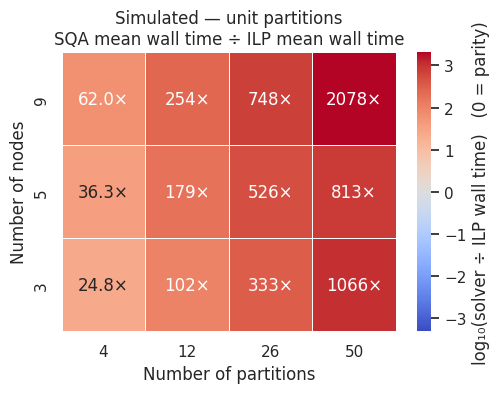

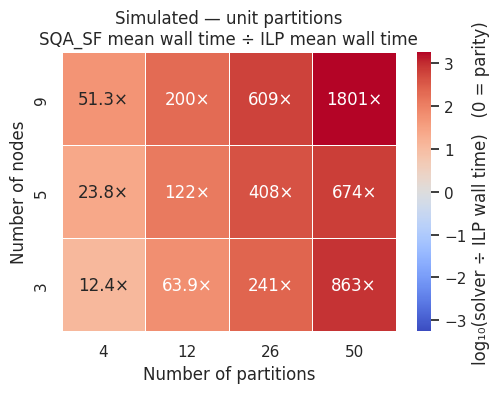


================  QPU  ================


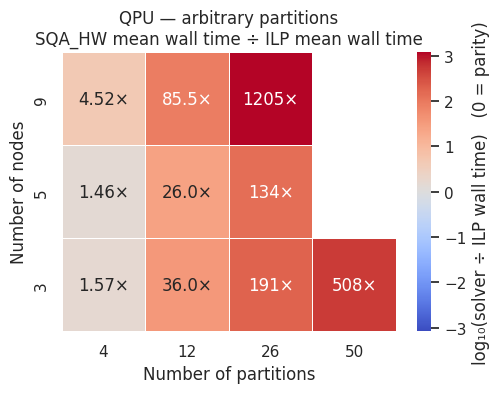

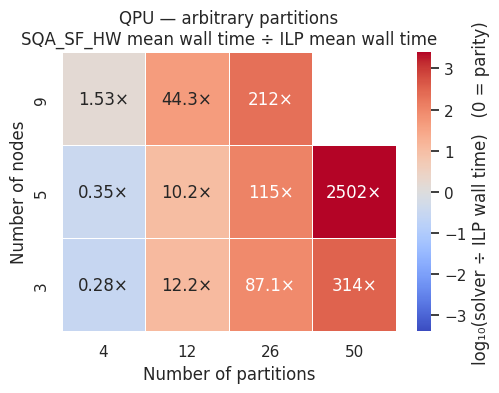

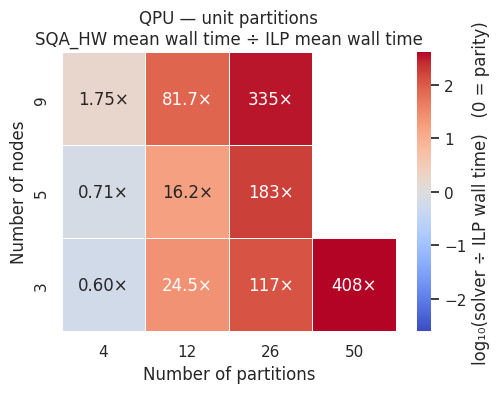

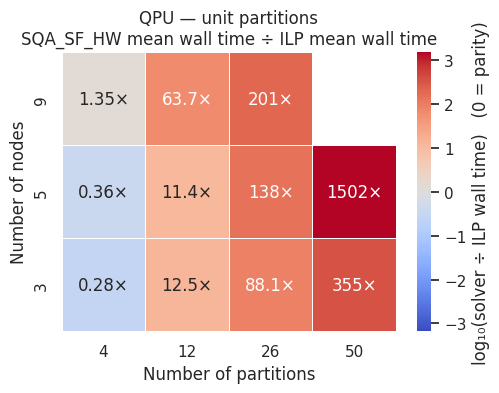


================  Hybrid  ================


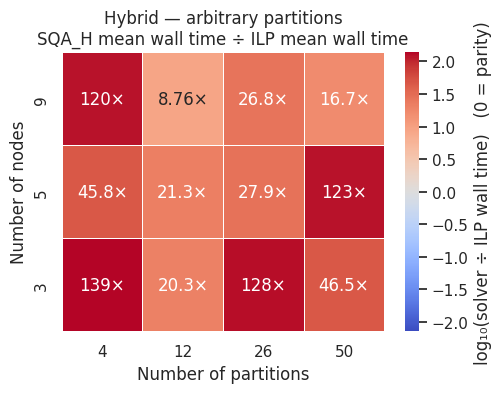

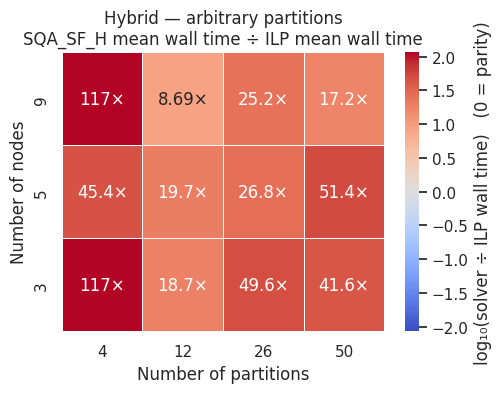

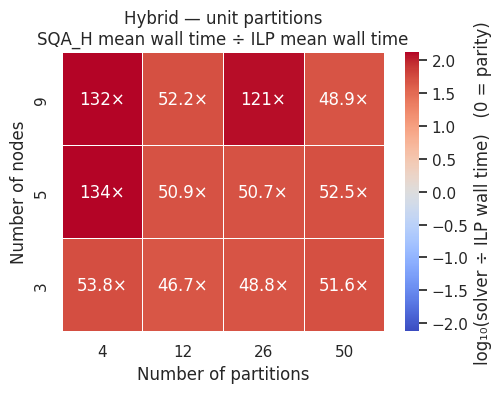

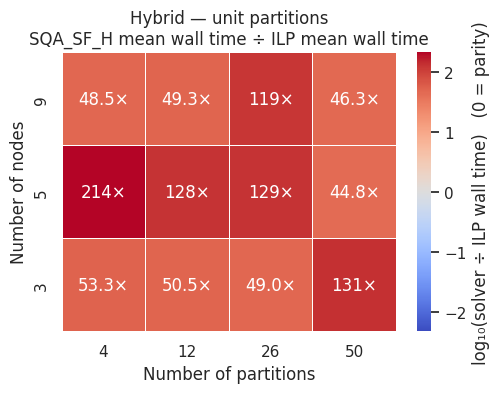

In [5]:
# --- Per regime x partition-mode x candidate solver: wall-time ratio heatmap --
# Iterates every regime, then each partition mode (arbitrary, unit) separately,
# then each candidate solver in that file -> one heatmap each.
for regime, modes in REGIMES.items():
    print(f"\n================  {regime}  ================")
    for mode in ("arbitrary", "unit"):
        sub_mode = df[(df["regime"] == regime) & (df["mode"] == mode)]
        if sub_mode.empty:
            print(f"  [{mode}] no data")
            continue
        for solver in sorted(sub_mode["solver"].unique()):
            sub = sub_mode[sub_mode["solver"] == solver]
            agg = sub.groupby(["n_nodes", "n_partitions"]).agg(
                solver_mean=("solver_wall_ms", "mean"),
                ilp_mean=("ilp_wall_ms", "mean"),
            )
            agg["ratio"] = agg["solver_mean"] / agg["ilp_mean"]
            pivot = agg["ratio"].unstack("n_partitions")
            ratio_heatmap(
                pivot,
                title=f"{regime} — {mode} partitions\n{solver} mean wall time ÷ ILP mean wall time",
                fname=f"timing__{slug(regime)}__{mode}__{slug(solver)}__walltime_ratio_heatmap.png",
            )

## Summary table

In [6]:
# --- Text summary: overall wall-time ratio per regime/mode/solver ------------
# Median over cells of (mean solver wall / mean ILP wall), plus the raw mean
# wall times in ms, so the heatmaps have a one-line numeric companion.
recs = []
for (regime, mode, solver), sub in df.groupby(["regime", "mode", "solver"]):
    cell = sub.groupby(["n_nodes", "n_partitions"]).agg(
        s=("solver_wall_ms", "mean"), i=("ilp_wall_ms", "mean"))
    cell["r"] = cell["s"] / cell["i"]
    recs.append({
        "regime": regime, "mode": mode, "solver": solver,
        "median_ratio": round(cell["r"].median(), 2),
        "min_ratio": round(cell["r"].min(), 2),
        "max_ratio": round(cell["r"].max(), 2),
        "solver_wall_ms_mean": round(sub["solver_wall_ms"].mean(), 1),
        "ilp_wall_ms_mean": round(sub["ilp_wall_ms"].mean(), 1),
        "n_cases": len(sub),
    })
summary = pd.DataFrame(recs).sort_values(["regime", "mode", "solver"]).reset_index(drop=True)
summary

,regime,mode,solver,median_ratio,min_ratio,max_ratio,solver_wall_ms_mean,ilp_wall_ms_mean,n_cases
0,Hybrid,arbitrary,SQA_H,36.84,8.76,139.23,2615.7,65.8,36
1,Hybrid,arbitrary,SQA_SF_H,34.22,8.69,117.10,2059.5,65.8,36
2,Hybrid,unit,SQA_H,51.89,46.67,133.83,2346.6,33.7,36
3,Hybrid,unit,SQA_SF_H,51.91,44.79,213.61,2948.4,33.7,36
4,QPU,arbitrary,SQA_HW,60.77,1.46,1205.03,63524.3,234.7,150
5,QPU,arbitrary,SQA_SF_HW,44.27,0.28,2501.81,39875.9,234.2,156
6,QPU,unit,SQA_HW,53.13,0.60,407.71,28674.3,220.5,150
7,QPU,unit,SQA_SF_HW,63.68,0.28,1501.55,33221.7,221.2,156
8,Simulated,arbitrary,SQA,198.51,28.28,1106.47,23045.3,63.8,180
9,Simulated,arbitrary,SQA_SF,115.78,7.34,812.01,16950.7,63.8,180
